# Test the Barcelona-trained regression models on Berlin

Loads the pickled shallow-learning regressors and scaler trained on Barcelona (`notebooks/_elena/07_SL_save_model_regression.ipynb`, target **`noise_day` in dB**) and applies them to the Berlin dataset, comparing predicted dB with the real values from the strategic noise map.

Outputs go to `../results/`: a predictions CSV and an interactive map of the prediction error in dB.

Note: Berlin's day value is the per-segment Lden mean (24h composite), which runs slightly above a plain daytime level.

# Data and libraries

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

In [2]:
# load the Berlin regression dataset

data = pd.read_csv("data/ber_noise_regre_ml_dataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 70890 entries, 0 to 70889
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                70890 non-null  str    
 1   noise_day              70890 non-null  float64
 2   noise_evening          70890 non-null  float64
 3   noise_night            70890 non-null  float64
 4   road_category          70890 non-null  int64  
 5   dist_to_trunk          70890 non-null  float64
 6   dist_to_primary        70890 non-null  float64
 7   dist_to_secondary      70890 non-null  float64
 8   dist_to_tertiary       70890 non-null  float64
 9   dist_to_residential    70890 non-null  float64
 10  dist_to_living_street  70890 non-null  float64
 11  signals                70890 non-null  float64
 12  transport              70890 non-null  float64
 13  pois                   70890 non-null  float64
 14  width                  70890 non-null  float64
 15  betweenness  

# Load the Barcelona model artifacts

In [3]:
MODELS_DIR = '../../../notebooks/_elena/models'

with open(f'{MODELS_DIR}/Sscaler_regre.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(f'{MODELS_DIR}/feature_columns_regre.pkl', 'rb') as f:
    feature_columns = pickle.load(f)
with open(f'{MODELS_DIR}/linreg_regre_model.pkl', 'rb') as f:
    linreg_model = pickle.load(f)
with open(f'{MODELS_DIR}/xgb_regre_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
with open(f'{MODELS_DIR}/rf_regre_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

feature_columns

['road_category',
 'dist_to_trunk',
 'dist_to_primary',
 'dist_to_secondary',
 'dist_to_tertiary',
 'dist_to_residential',
 'dist_to_living_street',
 'signals',
 'transport',
 'pois',
 'width',
 'betweenness',
 'closeness_global',
 'closeness_400',
 'straightness',
 'green',
 'industrial',
 'commercial']

In [4]:
# arrange the columns in the exact order the scaler/models were trained on, then scale

X = data[feature_columns]
X_scaled = scaler.transform(X)
y_true = np.asarray(data['noise_day'], dtype=float)

# Predict and compare with the real values

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': linreg_model,
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
}

predictions = {}
rows = []
for name, model in models.items():
    y_pred = np.asarray(model.predict(X_scaled), dtype=float)
    predictions[name] = y_pred
    rows.append({
        'model': name,
        'r2': r2_score(y_true, y_pred),
        'mae_db': mean_absolute_error(y_true, y_pred),
        'rmse_db': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mean_error_db': np.mean(y_pred - y_true),
    })

summary = pd.DataFrame(rows).set_index('model').round(3)
summary

,r2,mae_db,rmse_db,mean_error_db
model,,,,
Linear Regression,-0.368,8.420,10.041,6.412
XGBoost,0.166,6.474,7.839,2.913
Random Forest,0.111,6.895,8.093,3.524


### Derived classes
Binning the predicted dB into the usual classes (`0: <40, 1: 40–50, 2: 50–60, 3: 60–70, 4: ≥70`) makes the regression directly comparable with the classification transfer results.

In [6]:
class_bins = [40, 50, 60, 70]
y_true_class = np.digitize(y_true, class_bins)

rows = []
for name in models:
    pred_class = np.digitize(predictions[name], class_bins)
    rows.append({
        'model': name,
        'derived_accuracy': np.mean(pred_class == y_true_class),
        'within_1_class': np.mean(np.abs(pred_class - y_true_class) <= 1),
    })

pd.DataFrame(rows).set_index('model').round(4)

,derived_accuracy,within_1_class
model,,
Linear Regression,0.3146,0.8499
XGBoost,0.3894,0.9346
Random Forest,0.3367,0.9470


### Predicted vs real dB

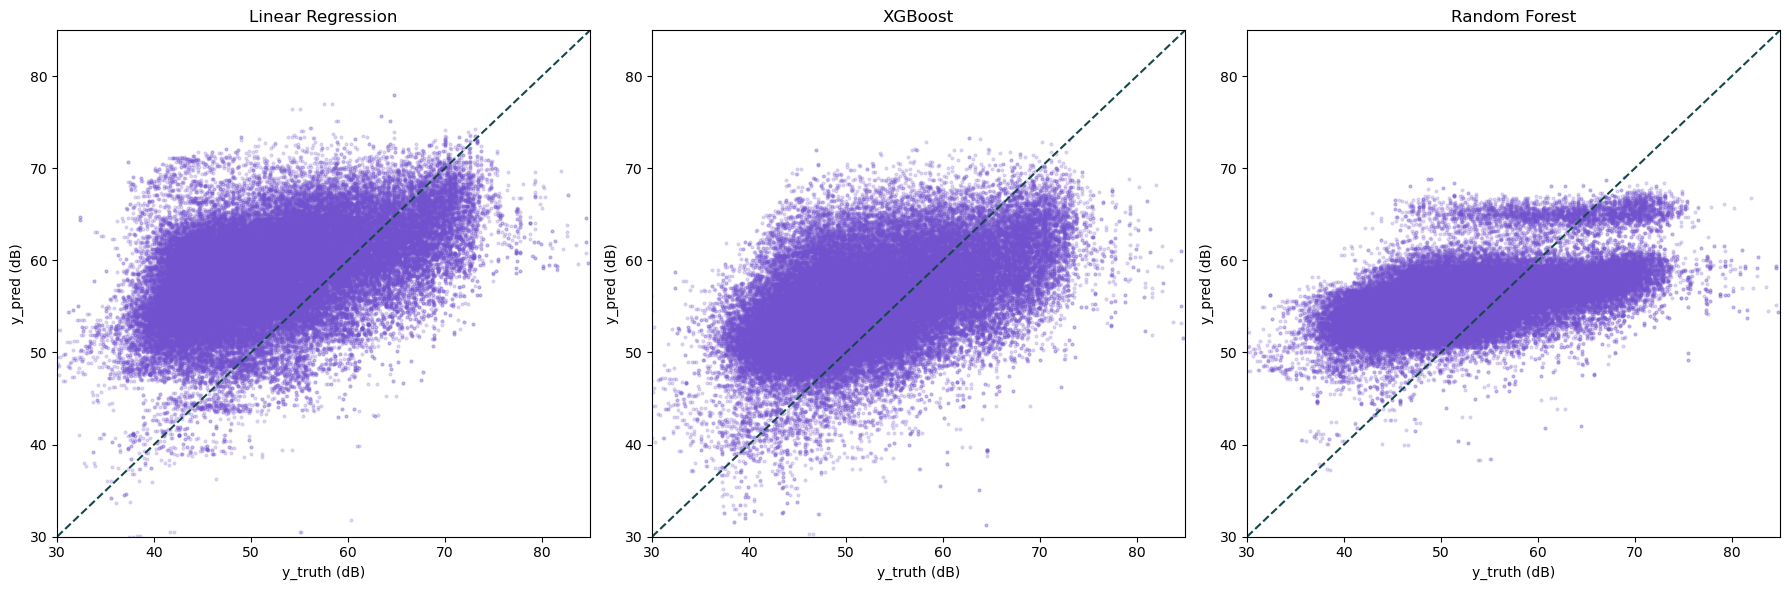

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name in zip(axes, models):
    ax.scatter(y_true, predictions[name], color='#7251ce', s=4, alpha=0.2)
    ax.axline((50, 50), slope=1, ls='--', color='#144849')
    ax.set_title(name)
    ax.set_xlabel('y_truth (dB)')
    ax.set_ylabel('y_pred (dB)')
    ax.set_xlim(30, 85)
    ax.set_ylim(30, 85)
plt.tight_layout()
plt.show()

# Export results

In [8]:
os.makedirs('../results', exist_ok=True)

results = data[['road_id', 'noise_day']].rename(columns={'noise_day': 'db_day_true'}).copy()
results['pred_linreg'] = predictions['Linear Regression'].round(2)
results['pred_xgb'] = predictions['XGBoost'].round(2)
results['pred_rf'] = predictions['Random Forest'].round(2)
results['db_diff_linreg'] = (results['pred_linreg'] - results['db_day_true']).round(2)

results.to_csv('../results/ber_bcn_model_regre_predictions.csv', index=False)
results.head()

,road_id,db_day_true,pred_linreg,pred_xgb,pred_rf,db_diff_linreg
0,172539_172562_0,53.849999,68.69,57.40,64.30,14.84
1,172539_34694336_0,55.025000,66.14,59.18,57.80,11.12
2,172539_34694265_0,59.366667,65.93,58.05,56.75,6.56
3,172545_271370539_0,65.300003,67.06,59.65,58.10,1.76
4,172545_34694336_0,57.033333,68.00,56.89,58.55,10.97


### Visualise prediction error on the map

`db_diff = predicted − real` dB for the Linear Regression: blue = underestimated, red = overestimated, white = correct.

The map is saved to HTML only — open `../results/ber_map_db_diff_linreg.html` in a browser.

In [9]:
osm_roads = gpd.read_file('../layers/BER_noise_streets.gpkg')
merged_gdf = osm_roads.merge(results, left_on='segment_id', right_on='road_id', how='left')

m = merged_gdf.to_crs(epsg=4326).explore(
    column='db_diff_linreg',
    cmap='RdBu_r',
    vmin=-15, vmax=15,
    tiles='CartoDB positron',
    tooltip=['road_id', 'db_diff_linreg', 'pred_linreg', 'db_day_true', 'highway'],
    legend=True,
)
m.save('../results/ber_map_db_diff_linreg.html')
print('saved ../results/ber_map_db_diff_linreg.html')

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


saved ../results/ber_map_db_diff_linreg.html
